# 00 · Setup and data

This is the first of four notebooks that walk through **GPU_HYPE**, the GPU-assisted, multi-objective calibration and probabilistic forecasting tool for the [HYPE](https://hypeweb.smhi.se/) hydrological model published alongside the paper.

| Notebook | Topic |
|---|---|
| **00 · Setup and data** *(this one)* | environment, the HYPE folder and the data formats |
| [01 · Calibration](01_calibration.ipynb) | the calibration tool: build `HYPE` + `Error` + `GPU_PSO` and run a short `fit` |
| [02 · Training and predicting](02_training_and_predicting.ipynb) | load the pre-trained model and forecast a probabilistic ensemble |
| [03 · Results](03_results.ipynb) | hydrographs with uncertainty bands, reliability, and skill metrics |

All four run with the working directory at the **repository root** and use the bundled **Türkheim** catchment under [`examples/`](../examples).

> **Requirements.** A runnable end-to-end pipeline needs **Windows** (the HYPE model is a `.exe`) and a working **OpenCL** platform (a GPU, or a CPU OpenCL runtime). See the [README](../README.md#system-requirements).

In [1]:
from pathlib import Path

## 1 · The HYPE folder

A **HYPE folder** is a standard HYPE setup directory. The wrapper copies it several times into a temporary directory and runs those copies in parallel, one per population sub-batch. The bundled example is the **Türkheim** sub-catchment (outlet subbasin `50675`).

Key files:

| File | Role |
|---|---|
| `info.txt` | simulation dates (`bdate`/`cdate`/`edate`) and `basinoutput` settings |
| `par.txt` | model parameters (the calibration targets live here) |
| `GeoData.txt`, `GeoClass.txt` | subbasin topology and land-use classes |
| `Pobs.txt`, `Tobs.txt`, `TMINobs.txt`, `TMAXobs.txt` | meteorological forcing |
| `HYPEwithoutPopup4All.exe` | the HYPE executable the wrapper calls |

In [2]:
HYPE_FOLDER = Path("demo_model\HYPE_setup_folder")
for f in sorted(HYPE_FOLDER.iterdir()):
    print(f"{f.stat().st_size:>10,d}  {f.name}")

       375  AquiferData_Example.txt
       427  ClassData.txt
       339  description.txt
         2  filedir.txt
        73  FloodData_Example.txt
       416  ForcKey.txt
       466  GeoClass.txt
     3,113  GeoData.txt
 4,138,867  HYPEwithoutPopup4All.exe
       383  info.txt
       164  optpar.txt
       705  par.txt
        24  pmsf.txt
    41,681  Pobs.txt
       223  PointSourceData.txt
     4,096  results
    54,604  Tobs.txt
     8,355  Xobs.txt


In [3]:
# Simulation window and output subbasin are declared in info.txt
for line in (HYPE_FOLDER / "info.txt").read_text().splitlines():
    if line.startswith(("bdate", "cdate", "edate", "resultdir")) or "subbasins" in line:
        print(line)

resultdir		.\results\
bdate      		2001-01-01
cdate      		2001-01-01
edate      		2001-12-31
basinoutput	subbasins	3587


## 2 · Observed discharge

The observations used to score the calibration are the daily discharge at the outlet (subbasin `50675`). They are stored tab-separated with a `Date` column.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

obs = pd.read_csv(Path("demo_model\Qobs.txt"), sep="\t", header=0,
                  index_col="DATE", parse_dates=True)
discharge = obs["3587"]
print("records:", len(discharge), "| from", discharge.index.min().date(), "to", discharge.index.max().date())
discharge.head()

records: 365 | from 2001-01-01 to 2001-12-31


DATE
2001-01-01    5.086
2001-01-02    4.996
2001-01-03    4.996
2001-01-04    5.003
2001-01-05    5.010
Name: 3587, dtype: float64

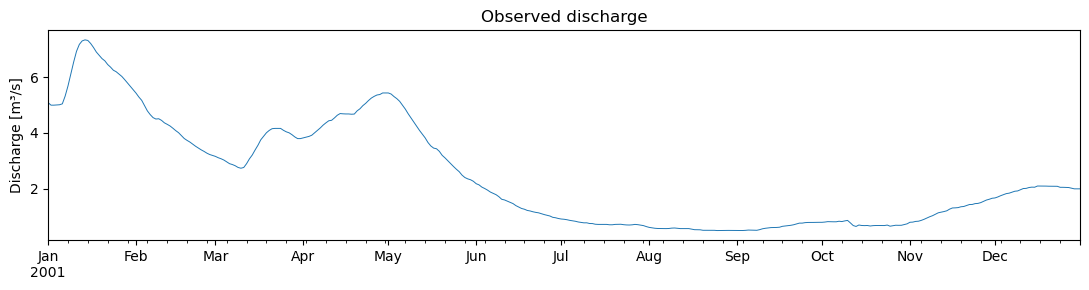

In [6]:
fig, ax = plt.subplots(figsize=(11, 3))
discharge.plot(ax=ax, lw=0.7)
ax.set_ylabel("Discharge [m\u00b3/s]")
ax.set_xlabel("")
ax.set_title("Observed discharge")
plt.tight_layout()

## 4 · Meteorological forcing

HYPE reads its forcing (precipitation, temperature) directly from the HYPE folder; you do not pass it to the optimiser. We load it here only to understand the inputs and to overlay it on the hydrograph later (notebook 03).

In [7]:
prec = pd.read_csv(HYPE_FOLDER / "Pobs.txt", sep="\t", header=0, parse_dates=True, index_col="DATE")
temp = pd.read_csv(HYPE_FOLDER / "Tobs.txt", sep="\t", header=0,index_col="DATE", parse_dates=True)
print("Precipitation columns (subbasins):", list(prec.columns))
print("Temperature columns (subbasins):", list(temp.columns))
prec.head()

Precipitation columns (subbasins): ['3344', '3396', '3407', '3466', '3558', '3555', '3607', '63804', '63931', '3564', '3581', '3547', '3594', '40556', '40541', '3486', '3361', '3427', '3435', '3432', '63794', '63938', '63937', '3532', '3587']
Temperature columns (subbasins): ['3344', '3396', '3407', '3466', '3558', '3555', '3607', '63804', '63931', '3564', '3581', '3547', '3594', '40556', '40541', '3486', '3361', '3427', '3435', '3432', '63794', '63938', '63937', '3532', '3587']


,3344,3396,3407,3466,3558,3555,3607,63804,63931,3564,...,3486,3361,3427,3435,3432,63794,63938,63937,3532,3587
DATE,,,,,,,,,,,,,,,,,,,,,
2001-01-01,14.100,14.2000,14.2000,13.8000,13.10,13.10,13.40,13.800,13.60000,13.50,...,12.900,14.000,13.9000,13.500,13.100,12.600,12.50000,12.4000,12.1000,11.7000
2001-01-02,4.310,4.1600,4.2600,4.4800,4.74,4.74,4.28,4.060,4.26000,4.33,...,4.810,4.480,4.5800,4.640,4.680,4.680,4.81000,4.6500,4.7500,4.8200
2001-01-03,2.780,2.7100,2.8400,2.9700,3.25,3.25,2.75,2.690,2.80000,2.82,...,3.370,2.910,3.0100,3.110,3.230,3.420,3.47000,3.5300,3.5300,3.5600
2001-01-04,0.116,0.0742,0.0777,0.0617,0.00,0.00,0.00,0.013,0.00119,0.00,...,0.064,0.125,0.0874,0.106,0.123,0.112,0.00157,0.0917,0.0521,0.0201
2001-01-05,3.560,3.3700,3.2800,3.2000,2.93,2.93,2.60,2.990,2.85000,2.75,...,3.140,3.590,3.3900,3.380,3.400,3.320,2.90000,3.2200,3.1000,2.9800


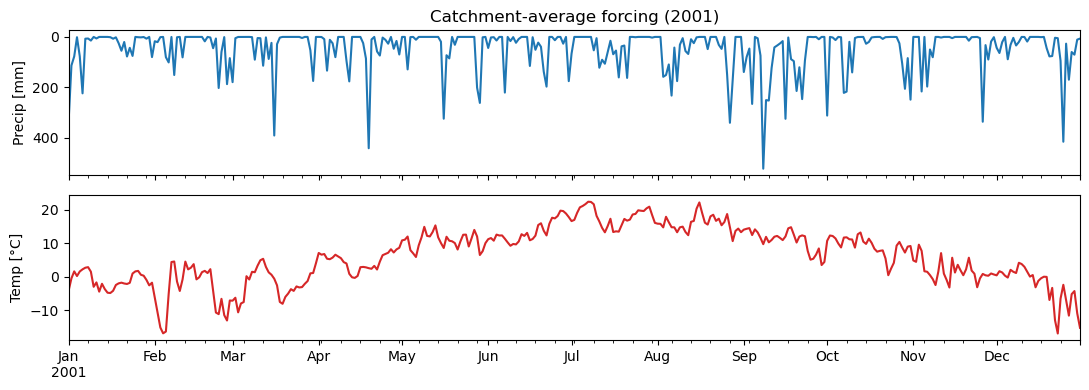

In [ ]:
fig, (axp, axt) = plt.subplots(2, 1, figsize=(11, 4), sharex=True)
prec.sum(axis=1).plot(ax=axp, color="tab:blue")
axp.set_ylabel("Precip [mm]"); axp.invert_yaxis()
temp.mean(axis=1).plot(ax=axt, color="tab:red")
axt.set_ylabel("Temp [\u00b0C]"); axt.set_xlabel("")
axp.set_title("Catchment-average forcing (2001)")
plt.tight_layout()

## Next

Everything is in place. Continue with [**01 · Calibration and Prediction**](01_calibration_and_prediction.ipynb) to set up the optimiser and run a short calibration on this catchment.